# Simulator Generation And Visualization

`tools/simulator/generator.py`로 샘플을 생성하고, 생성 결과를 바로 시각화하는 노트북입니다.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Video, display
from PIL import Image

plt.rcParams['figure.dpi'] = 140

In [2]:
NOTEBOOK_CWD = Path.cwd().resolve()

if (NOTEBOOK_CWD / 'generator.py').exists():
    SIM_ROOT = NOTEBOOK_CWD
elif (NOTEBOOK_CWD / 'tools' / 'simulator' / 'generator.py').exists():
    SIM_ROOT = (NOTEBOOK_CWD / 'tools' / 'simulator').resolve()
else:
    raise FileNotFoundError('`generator.py`를 찾을 수 없습니다. `tools/simulator`에서 열거나 프로젝트 루트에서 실행해 주세요.')

PROJECT_ROOT = SIM_ROOT.parents[1]
OUT_ROOT = SIM_ROOT / 'data' / 'generated_v2_notebook'

print('SIM_ROOT   =', SIM_ROOT)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUT_ROOT   =', OUT_ROOT)

SIM_ROOT   = /media/hdd0/whyz/structure-stability/tools/simulator
PROJECT_ROOT = /media/hdd0/whyz/structure-stability
OUT_ROOT   = /media/hdd0/whyz/structure-stability/tools/simulator/data/generated_v2_notebook


In [3]:
GEN_CFG = {
    'out_root': OUT_ROOT,
    'prefix': 'NB',
    'start_index': 1,
    'count': 4,
    'seed': 42,
    'mode': 'random',  # stable | unstable | random
}
GEN_CFG

{'out_root': PosixPath('/media/hdd0/whyz/structure-stability/tools/simulator/data/generated_v2_notebook'),
 'prefix': 'NB',
 'start_index': 1,
 'count': 4,
 'seed': 42,
 'mode': 'random'}

In [4]:
cmd = [
    sys.executable,
    'generator.py',
    '--out-root', str(GEN_CFG['out_root']),
    '--prefix', GEN_CFG['prefix'],
    '--start-index', str(GEN_CFG['start_index']),
    '--count', str(GEN_CFG['count']),
    '--seed', str(GEN_CFG['seed']),
    '--mode', GEN_CFG['mode'],
]

result = subprocess.run(
    cmd,
    cwd=SIM_ROOT,
    text=True,
    capture_output=True,
    check=True,
)

print(result.stdout)
if result.stderr.strip():
    print('[stderr]')
    print(result.stderr)

generated: NB_0001 -> unstable
generated: NB_0002 -> unstable
generated: NB_0003 -> stable
generated: NB_0004 -> unstable
saved summary: /media/hdd0/whyz/structure-stability/tools/simulator/data/generated_v2_notebook/generated_summary.json

[stderr]
pybullet build time: Jan 29 2025 23:16:28



In [5]:
summary_path = Path(GEN_CFG['out_root']) / 'generated_summary.json'
with summary_path.open('r', encoding='utf-8') as f:
    summary_rows = json.load(f)

summary_df = pd.DataFrame(summary_rows)
summary_df

,id,seed,scene_seed,sim_seed,mode_requested,unstable_requested,label,detected_label,mode_match,mode_attempts,fps,frames,resolution,render,physics,num_blocks
0,NB_0001,42,500057,147626724,stable,False,unstable,unstable,False,6,30,300,"[384, 384]",pybullet_hardware_opengl,pybullet_rigid_body,12
1,NB_0002,43,100046,39247829,unstable,True,unstable,unstable,True,2,30,300,"[384, 384]",pybullet_hardware_opengl,pybullet_rigid_body,13
2,NB_0003,44,500059,150955774,stable,False,stable,stable,True,6,30,300,"[384, 384]",pybullet_hardware_opengl,pybullet_rigid_body,10
3,NB_0004,45,45,1088807848,unstable,True,unstable,unstable,True,1,30,300,"[384, 384]",pybullet_hardware_opengl,pybullet_rigid_body,12


In [6]:
if summary_df.empty:
    raise RuntimeError('생성된 샘플이 없습니다.')

SELECT_INDEX = 0
selected = summary_df.iloc[SELECT_INDEX].to_dict()
sample_dir = Path(GEN_CFG['out_root']) / selected['id']

front_path = sample_dir / 'front.png'
top_path = sample_dir / 'top.png'
video_path = sample_dir / 'simulation.mp4'
meta_path = sample_dir / 'meta.json'

print('sample_dir =', sample_dir)
selected

sample_dir = /media/hdd0/whyz/structure-stability/tools/simulator/data/generated_v2_notebook/NB_0001


{'id': 'NB_0001',
 'seed': 42,
 'scene_seed': 500057,
 'sim_seed': 147626724,
 'mode_requested': 'stable',
 'unstable_requested': False,
 'label': 'unstable',
 'detected_label': 'unstable',
 'mode_match': False,
 'mode_attempts': 6,
 'fps': 30,
 'frames': 300,
 'resolution': [384, 384],
 'render': 'pybullet_hardware_opengl',
 'physics': 'pybullet_rigid_body',
 'num_blocks': 12}

In [7]:
with meta_path.open('r', encoding='utf-8') as f:
    meta = json.load(f)

meta

{'id': 'NB_0001',
 'seed': 42,
 'scene_seed': 500057,
 'sim_seed': 147626724,
 'mode_requested': 'stable',
 'unstable_requested': False,
 'label': 'unstable',
 'detected_label': 'unstable',
 'mode_match': False,
 'mode_attempts': 6,
 'fps': 30,
 'frames': 300,
 'resolution': [384, 384],
 'render': 'pybullet_hardware_opengl',
 'physics': 'pybullet_rigid_body',
 'num_blocks': 12}

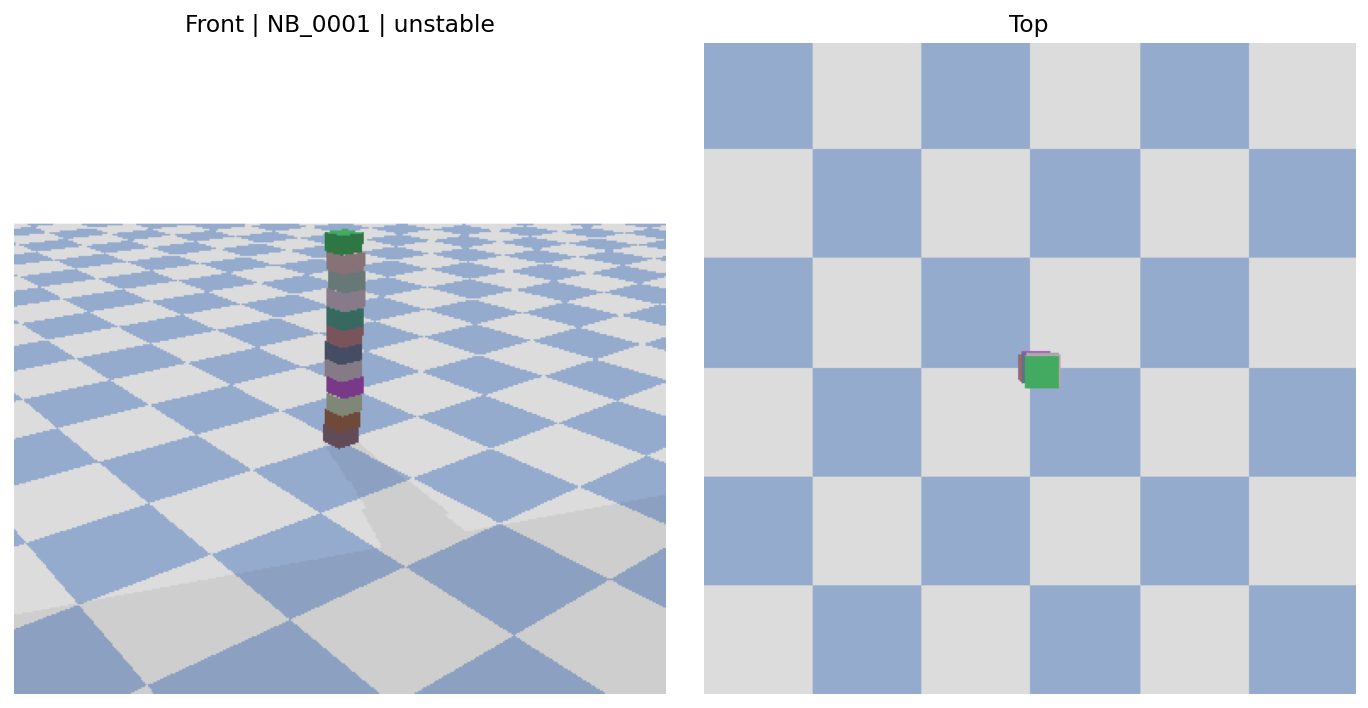

In [8]:
front_img = Image.open(front_path)
top_img = Image.open(top_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(front_img)
axes[0].set_title(f"Front | {meta['id']} | {meta['label']}")
axes[0].axis('off')

axes[1].imshow(top_img)
axes[1].set_title('Top')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [9]:
display(Video(filename=str(video_path), embed=True, html_attributes='controls loop'))

In [10]:
preview_rows = []
for row in summary_rows:
    sample_id = row['id']
    preview_rows.append({
        'id': sample_id,
        'label': row['label'],
        'mode_requested': row['mode_requested'],
        'mode_match': row['mode_match'],
        'num_blocks': row['num_blocks'],
        'front_path': str(Path(GEN_CFG['out_root']) / sample_id / 'front.png'),
    })

preview_df = pd.DataFrame(preview_rows)
preview_df[['id', 'label', 'mode_requested', 'mode_match', 'num_blocks']]

,id,label,mode_requested,mode_match,num_blocks
0,NB_0001,unstable,stable,False,12
1,NB_0002,unstable,unstable,True,13
2,NB_0003,stable,stable,True,10
3,NB_0004,unstable,unstable,True,12


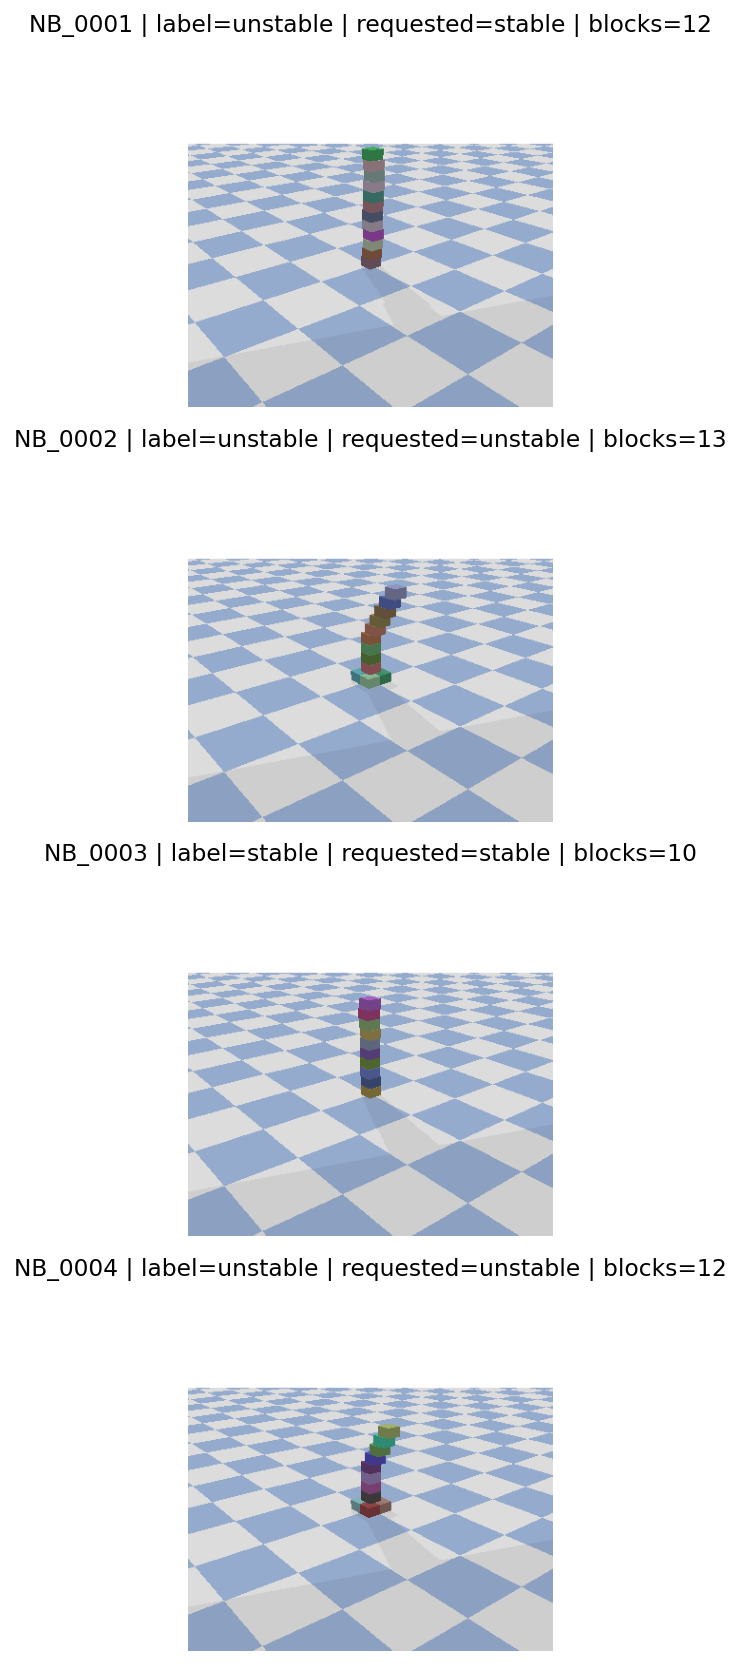

In [11]:
n = len(preview_df)
fig, axes = plt.subplots(n, 1, figsize=(6, max(3, 3 * n)))
if n == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, preview_df.iterrows()):
    ax.imshow(Image.open(row['front_path']))
    ax.set_title(f"{row['id']} | label={row['label']} | requested={row['mode_requested']} | blocks={row['num_blocks']}")
    ax.axis('off')

plt.tight_layout()
plt.show()